# Assignment 2: Molecular Dynamics of n-Pentane

**6EMA02 Particle-based Simulations, 2026-2027 edition**
United-atom force field · liquid n-pentane · conformers and diffusion

## How this assignment is assessed: read this first

This notebook is both the assignment text and your report. Task cells
(like this one) are the assignment text and are marked read-only. Jupyter
enforces that; some editors (VS Code among them) do not, so simply leave
them untouched either way: hand-ins are checked against the released
notebook, and modified task cells are flagged. You write your answers in
the cells below each task and hand in this same notebook, **executed**,
together with an HTML export, your code, and the data files the notebook
loads (layout at the end of this notebook).

Your report is **not graded on its content**. Its result is determined in
the individual oral examination at the end of the quartile: the exam is a
conversation about *your* code and *your* results, with this notebook on
screen. Write it as your defence dossier: concise, bullet answers are
fine, every claim something you can stand behind. A report you never hand
in scores 0 for its weight in the final grade; a handed-in report's
result *is* your oral grade.

**AI and sources.** You may use AI assistants (ChatGPT, Claude, Copilot,
…) freely in this course, for code, analysis, and text. Declare the use
briefly in the *Sources* section below, along with any other external
sources: anything in your submission (code, text, data, results) that
your group did not produce itself. Declared sources are never penalised:
nobody grades the text of your report or the style of your code. The oral
examination assesses what *you* understand about the simulation you hand
in. Anything in your submission is fair game, and "we didn't write that
part" is not an available answer. Presenting undeclared external work as
your own is academic misconduct and is treated as such.

## Group

- **Group ID:** 5
- **Members:** Olivier Jakub Toczyski (), Thomas Dadikozyan (student ID)

## The physics: what molecular dynamics does

Molecular dynamics answers a simple question with a lot of consequences:
if we knew the force on every atom, and we integrated Newton's equations
of motion for all of them, what would the material do?

The machinery is exactly what you built in A1. Positions and velocities
evolve under

$$m_i \frac{\mathrm{d}^2 \mathbf{r}_i}{\mathrm{d}t^2} = \mathbf{F}_i =
-\nabla_i U(\mathbf{r}_1, \ldots, \mathbf{r}_N),$$

integrated with velocity-Verlet. What changes is the potential energy
$U$, and the consequences of that change reach into every part of the
program:

- **The interactions are short ranged.** Gravity reaches across the solar
  system, so A1 could afford all $N(N-1)/2$ pairs. The Lennard-Jones
  interaction is negligible beyond a few molecular diameters, so we cut
  it off and only ever look at nearby pairs. That is what the cell-linked
  list and Verlet neighbour list in the provided code are for: they turn
  an $O(N^2)$ force evaluation into $O(N)$.
- **The system is periodic.** A few thousand molecules in a box with
  walls would be almost all surface. Periodic boundary conditions with
  the minimum-image convention give a bulk liquid instead.
- **The molecules have internal structure.** Besides the non-bonded
  interactions there are bonds, angles and torsions, which is where the
  chemistry of pentane enters.
- **Temperature is a thing you control.** A thermostat lets you sample a
  constant-temperature (NVT) ensemble instead of constant energy (NVE).

Why any of this is worth doing: from the trajectory you can measure
quantities that are hard or impossible to get any other way. In this
assignment you measure two of them, each testing a different layer of the
simulation. The conformer populations test the free-energy landscape of a
single molecule, and reveal the **pentane effect**, a genuinely subtle
piece of chemistry. The mean-squared displacement gives a transport
coefficient, the self-diffusion coefficient, through the Einstein
relation

$$\left\langle |\mathbf{r}_\mathrm{cm}(t) - \mathbf{r}_\mathrm{cm}(0)|^2
\right\rangle \xrightarrow{\ t\ \text{large}\ } 6 D t .$$

## The model: a united-atom force field for n-pentane

**The molecule.** n-Pentane is
$\mathrm{CH}_3$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_3$.
We do not simulate the hydrogens. In a **united-atom** model each
$\mathrm{CH}_3$ or $\mathrm{CH}_2$ group is one interaction site with the
mass of the whole group. Two reasons: it removes two thirds of the sites,
and, more importantly, it removes the fastest motion in the system. A
C-H bond vibrates with a period of about 10 fs, which would force a time
step of roughly 0.1 fs; without hydrogens, 1 fs is enough.

Each molecule therefore has 5 sites, **4 bonds, 3 angles and 2
dihedrals** ($\phi_1$ over atoms 1-2-3-4 and $\phi_2$ over atoms
2-3-4-5). The two dihedrals share three atoms, which is what makes their
statistics *coupled* rather than independent, and that coupling is the
subject of task C2.

**State point:** density $\rho = 626\ \mathrm{kg/m^3}$ and
$T = 293$ K, which is liquid pentane at ambient conditions.

### Non-bonded: Lennard-Jones

$$U_{\mathrm{LJ}}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} -
\left(\frac{\sigma}{r}\right)^{6}\right] - U_{\mathrm{LJ}}(r_{\text{cut}})
\quad \text{for } r \le r_{\text{cut}},$$

and zero beyond. Use $r_\text{cut} = 14$ Å. The $r^{-6}$ term is the
attractive dispersion interaction that holds the liquid together; the
$r^{-12}$ term is the repulsion that keeps sites apart. Subtracting
$U_{\mathrm{LJ}}(r_\text{cut})$ shifts the potential to zero at the
cut-off, so that no energy jump occurs when a pair crosses it.

| Site | $\epsilon/k_B$ (K) | $\sigma$ (Å) | mass (amu) |
|------|-----|------|------|
| $\mathrm{CH}_3$ | 98.0 | 3.75 | 15.035 |
| $\mathrm{CH}_2$ | 46.0 | 3.95 | 14.027 |

Cross terms follow the Lorentz-Berthelot mixing rules,
$\sigma_{ij} = \tfrac12(\sigma_i + \sigma_j)$ and
$\epsilon_{ij} = \sqrt{\epsilon_{ii}\,\epsilon_{jj}}$.

**Exclusions.** Within a molecule, the 1-2, 1-3 and 1-4 pairs must
**not** interact through Lennard-Jones: their geometry is already fixed
by the bond, angle and torsion terms, and counting both would be double
counting. The **1-5 pair does interact**, and that single interaction,
between the two end groups, is what makes the pentane effect of task C2
appear.

### Bonded terms

$$U_{\mathrm{bond}}(r) = \tfrac12 k_b (r - r_0)^2, \qquad
r_0 = 1.54\ \text{Å}, \quad k_b/k_B = 3.19\times10^{5}\ \text{K/Å}^2,$$

$$U_{\mathrm{angle}}(\theta) = \tfrac12 k_\theta (\theta - \theta_0)^2,
\qquad \theta_0 = 114^\circ, \quad
k_\theta/k_B = 6.25\times10^{4}\ \text{K rad}^{-2}.$$

For each of the two dihedral angles, the Ryckaert-Bellemans torsion

$$U_{\mathrm{tors}}(\phi) = c_0 + c_1\cos\phi + c_2\cos^2\phi +
c_3\cos^3\phi,$$

$$c_0/k_B = 1010.0\ \text{K},\quad c_1/k_B = -2018.9\ \text{K},\quad
c_2/k_B = 136.4\ \text{K},\quad c_3/k_B = 3165.3\ \text{K}.$$

This has its global minimum at $\phi = 180^\circ$ (*trans*) and local
minima near $\pm 60^\circ$ (*gauche*), separated by barriers of several
$k_BT$. Those barriers are the reason conformer statistics converge
slowly: a molecule sits in one state for a long time and flips rarely, so
what you are sampling is a **rare event**, which task C2 asks you to
think about quantitatively.

A force field like this one is *empirical*: the functional forms are
chosen for convenience and the parameters are fitted, here to
thermodynamic data for alkanes. Nothing guarantees it reproduces a
property it was not fitted to. That is the difference between
verification (Part B: does my code implement this model correctly?) and
validation (Part C: does this model describe real pentane?).

## The code, and your working environment

The starting code is `MD_student_v7.0.0.zip` under Files ▸ Code. It is a
working Lennard-Jones molecular dynamics program: your job is to extend
it into a pentane simulator. Unpacking it gives you a folder
`MD_student_v7.0.0`; rename that to `code/` in your working directory, so
that the paths in this notebook and in the hand-in layout line up.

**The files.** `main.c` holds the whole control flow and is the place to
start reading. Then: `constants.h` (compile-time constants),
`structs.h` (all data types), `memory.c` (allocation and freeing),
`setparameters.c` (**the only place run configuration lives**: there are
no input files, you recompile to change a run), `random.c`,
`initialise.c` (initial positions, velocities, topology), `nbrlist.c`
(cell-linked list and Verlet neighbour list), `forces.c` (your main work
site), `dynamics.c` (the velocity-Verlet halves, boundary conditions,
thermostat), `fileoutput.c` (`.pdb` trajectories and restart files), and
`force_test.c` (the finite-difference force and virial checker you will
use in B3 and B5).

**The task list.** Open `html/index.html` from the zip: the Doxygen
documentation of the code has a generated *todo list* with every
`\todo` marker you must fill in. Treat it as the checklist for Part B.

**Build and run** (Linux and macOS; on Windows use MSYS2 or the provided
VS Code tasks):

```
gcc -O3 *.c -o md -lm                      # production
gcc -g -Wall -Wextra *.c -o md_debug -lm   # debugging
./md > run.csv
```

**House rules when extending.** New functions get a prototype in the
matching `.h`. New per-particle arrays are added to a struct in
`structs.h`, allocated in `alloc_memory` and freed in `free_memory`.
Internal units are the reduced units of task A1, not SI.

**Visualisation.** The code writes `.pdb` trajectories; open them in
OVITO (ovito.org). Look at your system early and often: most bugs in
this assignment are visible before they are measurable.

**Python environment.** The same `pbs-env` you set up for A1, from
`requirements.txt` (Files ▸ Assignments); the Canvas page *Working on the
assignments* has the details. The helper scripts are unchanged:
`nb2html.py` writes the HTML you hand in, `check_my_submission.py`
checks your zip before you submit it.

## Code map: fill in as you go

The examiner uses this table in the oral to jump straight to your code,
so **make the entries clickable links**: a markdown link with a path
relative to this notebook, for example

```
| B4 bonded forces | [`calculate_forces_bond`](code/forces.c) | [nve_molecule.csv](data/nve_molecule.csv) |
```

Relative paths only (`code/…`, `data/…`); everything you link to must be
inside the zip you hand in. `check_my_submission.py` verifies this.

| Task | File / function(s) | Data files |
|------|--------------------|------------|
| B1 I/O | [`main`](code/main.c) | [CSV check](data/b1_output_check.csv) |
| B2 types + LJ | [`initialise_types`, `initialise_velocities`](code/initialise.c), [`update_velocities_half_dt`](code/dynamics.c), [`calculate_forces_nb`](code/forces.c) | [force check](data/b3_forcecheck.txt), [NVE 1 fs](data/b3_nve_1fs.csv), [NVE 0.5 fs](data/b3_nve_05fs.csv), [NVT continuation](data/b3_equil_long.csv) |
| B4 bonded forces | … | … |
| B6 initialization | … | … |
| B8 thermostat | … | … |
| C1 conformer analysis | … | … |
| C2 MSD and diffusion | … | … |

## Sources

**AI tools used:** OpenAI Codex (B1–B3 assistance).
**Used for:** reviewing the existing type-dependent masses and LJ implementation,
analysing saved CSV and force-check output, and drafting B1–B3 explanations and plots.
**Other external sources:** course-supplied MD starter code and assignment text.
Add any other sources or earlier AI assistance used by the group.
**Parts with substantial AI-assisted content:** B1–B3 report text and
[`analyse_b123.py`](code/analyse_b123.py), also included in the notebook below.
**Verification performed in this session:** compiled the C code and executed the
analysis against the saved data, including numerical CSV consistency checks.
The group still needs to review these explanations and complete the equilibrium test.


## Build & run log

- Review on 2026-09-29, Windows with MSYS2 GCC: from the notebook directory,
  `gcc -O3 -Wall -Wextra code/*.c -o md_b123_check.exe -lm` succeeded
  (about 2 s). Warnings include unfinished bonded routines and the existing
  `%lu`/`size_t` format in the XYZ writer.
- The analysis below was executed using the existing `../pbs-env` Python
  environment. All plotted simulation data already existed before this review;
  no new production trajectory was generated in this session.
- Saved NVE output spans 50 ps: 50,000 steps at 1 fs and 100,000 at 0.5 fs,
  sampled every 10 and 20 steps respectively. These step counts and intervals
  are verified from the CSV files. The exact historical build commands, wall
  times and parameter snapshots were not saved here; they must not be invented.
- For future runs: edit `code/setparameters.c`, then from `code/` run
  `gcc -O3 *.c -o md -lm` and `./md > ../data/NEW_RUN.csv`
  (PowerShell: `./md.exe | Out-File -Encoding utf8 ../data/NEW_RUN.csv`).
  Use a new output name and archive the parameter settings for each run.
  Restart and trajectory paths in the current configuration are relative to `code/`.


## Part A: Modeling

*In the oral you should be able to:* state your unit system and convert
any quantity in this notebook to SI; derive each bonded force from its
potential; explain why the four torsion forces sum to zero and exert no
net torque.

### A1) Units

It is common practice to introduce non-standard units in simulations. In
your code, use Kelvin for the energy scale (that is, the energy unit is
$k_B \times 1$ K), Å for distances, and atomic mass units (amu) for
masses. The time unit follows from these.

Deliver: the derivation of the time unit, its value in SI, and the time
step of 1 fs expressed in internal units. State also the internal-unit
values you will use for $\epsilon$, $\sigma$, $k_b$ and $k_\theta$, and
one sanity check that your conversion is right (for example, the thermal
velocity of a $\mathrm{CH}_2$ site at 293 K, in both unit systems).

The chosen base units are

$$
E_0=k_B(1\ \mathrm{K})=1.380649\times10^{-23}\ \mathrm{J},
\qquad
L_0=1\ \mathrm{\AA}=10^{-10}\ \mathrm{m},
\qquad
M_0=1\ \mathrm{amu}=1.66054\times10^{-27}\ \mathrm{kg}.
$$

A quantity in internal units is its physical value divided by the
corresponding unit scale. Superscript $*$ denotes an internal-unit value.

**Time unit and timestep**

Since energy has dimensions $ML^2/t^2$, the unit scales satisfy

$$
E_0=\frac{M_0L_0^2}{t_0^2}.
$$

Therefore,

$$
t_0=\sqrt{\frac{M_0L_0^2}{E_0}}
=\sqrt{
\frac{(1.66054\times10^{-27})(10^{-10})^2}
{1.380649\times10^{-23}}
}
\approx1.0967\times10^{-12}\ \mathrm{s}
=1.0967\ \mathrm{ps}.
$$

The required timestep of $1\ \mathrm{fs}$ is therefore

$$
\Delta t^*=\frac{\Delta t}{t_0}
=\frac{10^{-15}}{1.0967\times10^{-12}}
\approx9.1184\times10^{-4}.
$$

**Force-field parameters in internal units**

The Lennard-Jones energy parameter is expressed as
$\epsilon^*=\epsilon/E_0$. Since the supplied values are
$\epsilon/k_B$ in Kelvin, their numerical values can be used directly.
Similarly, distances given in angstroms can be used directly.

| Site type | $\epsilon^*$ | $\sigma^*$ | $m^*$ |
|-----------|-------------:|-----------:|------:|
| $\mathrm{CH}_3$ | 98.0 | 3.75 | 15.035 |
| $\mathrm{CH}_2$ | 46.0 | 3.95 | 14.027 |

For a mixed $\mathrm{CH}_3$–$\mathrm{CH}_2$ pair, the
Lorentz–Berthelot rules give

$$
\epsilon_{32}^*=\sqrt{98.0\times46.0}\approx67.1416,
\qquad
\sigma_{32}^*=\frac{3.75+3.95}{2}=3.85.
$$

For the bond potential, the force constant has dimensions of energy
per length squared, so

$$
k_b^*=\frac{k_bL_0^2}{E_0}=3.19\times10^5.
$$

For the angle potential, angles are evaluated in radians, giving

$$
k_\theta^*=\frac{k_\theta}{E_0}=6.25\times10^4
\quad\text{when the angular displacement is in radians}.
$$

The equilibrium values are

$$
r_0^*=1.54,
\qquad
\theta_0=114^\circ=\frac{114\pi}{180}\approx1.98968\ \mathrm{rad}.
$$

The Lennard-Jones cut-off is $r_{\mathrm{cut}}^*=14$.

**Sanity check: thermal speed of a CH2 site at 293 K**

We use the three-dimensional root-mean-square speed,

$$
v_{\mathrm{rms}}=\sqrt{\langle v_x^2+v_y^2+v_z^2\rangle}
=\sqrt{\frac{3k_BT}{m}}.
$$

In SI units, the site mass is

$$
m=14.027(1.66054\times10^{-27})
\approx2.32924\times10^{-26}\ \mathrm{kg}.
$$

Thus,

$$
v_{\mathrm{rms}}
=\sqrt{
\frac{3(1.380649\times10^{-23})(293)}
{2.32924\times10^{-26}}
}
\approx721.8\ \mathrm{m\,s^{-1}}.
$$

In internal units, $k_BT/E_0=293$ and $m^*=14.027$, so

$$
v_{\mathrm{rms}}^*
=\sqrt{\frac{3(293)}{14.027}}
\approx7.9161.
$$

The velocity unit is

$$
v_0=\frac{L_0}{t_0}
=\frac{10^{-10}}{1.0967\times10^{-12}}
\approx91.184\ \mathrm{m\,s^{-1}}.
$$

Converting the internal speed back to SI gives

$$
v_{\mathrm{rms}}=v_{\mathrm{rms}}^*v_0
\approx7.9161(91.184)
\approx721.8\ \mathrm{m\,s^{-1}},
$$

which agrees with the direct SI calculation.

### A2) Bonded forces

From the expressions for the bond, angle, and torsion potentials, derive
the corresponding forces. Express them in terms of the bond vectors
$\mathbf{r}_{ij}$, $\mathbf{r}_{kj}$, and $\mathbf{r}_{kl}$ as defined in
`forces.c`.

Deliver, for each of the three terms: the force on every participating
atom, and one sentence on how the expression behaves in an obvious limit
(for instance at the potential minimum). State explicitly why the four
torsion forces sum to zero and carry no net torque, and describe the
numerical test that would confirm both properties on your own
implementation.

The force on an atom is the negative gradient of the potential energy:

$$
\boxed{\mathbf F_s=-\nabla_{\mathbf r_s}U}.
$$

This means that the force acts towards decreasing energy. We apply the
chain rule to connect changes in atomic positions to changes in bond
length, bond angle, or torsion angle.

Following `forces.c`, the bond vectors are

$$
\mathbf r_{ij}=\mathbf r_i-\mathbf r_j,\qquad
\mathbf r_{kj}=\mathbf r_k-\mathbf r_j,\qquad
\mathbf r_{kl}=\mathbf r_k-\mathbf r_l.
$$

These point from $j$ to $i$, from $j$ to $k$, and from $l$ to $k$,
respectively. The code applies the minimum-image convention to them.
All forces below are contributions from one interaction and must be
added to the total forces on the participating atoms.

### 1. Bond-stretch forces

**Step 1: Describe the bond.**

Let

$$
\mathbf a=\mathbf r_{ij},\qquad r=|\mathbf a|.
$$

The bond potential is

$$
U_b=\frac12k_b(r-r_0)^2.
$$

It penalises both stretching and compression relative to the preferred
bond length $r_0$.

**Step 2: Differentiate the energy with respect to bond length.**

$$
\frac{\mathrm dU_b}{\mathrm dr}=k_b(r-r_0).
$$

**Step 3: Convert this into a force vector.**

The unit vector $\mathbf a/r$ points from $j$ towards $i$. Since

$$
\nabla_{\mathbf r_i}r=\frac{\mathbf a}{r},
$$

the chain rule gives

$$
\boxed{
\mathbf F_i
=-\frac{\mathrm dU_b}{\mathrm dr}\nabla_{\mathbf r_i}r
=-k_b(r-r_0)\frac{\mathbf a}{r}
}.
$$

The force on the other atom is opposite:

$$
\boxed{\mathbf F_j=-\mathbf F_i}.
$$

**Physical check:** at $r=r_0$, both forces vanish. If the bond is
stretched, the forces pull the atoms together; if compressed, they
push them apart.

### 2. Angle-bend forces

**Step 1: Express the angle using the bond vectors.**

For the angle $i$–$j$–$k$, the central atom is $j$. Define

$$
\mathbf a=\mathbf r_{ij},\qquad
\mathbf b=\mathbf r_{kj},\qquad
a=|\mathbf a|,\qquad b=|\mathbf b|.
$$

The dot-product identity gives

$$
q=\cos\theta=\frac{\mathbf a\cdot\mathbf b}{ab},
\qquad \theta=\arccos q.
$$

The angle potential is

$$
U_\theta=\frac12k_\theta(\theta-\theta_0)^2.
$$

**Step 2: Follow the chain of dependencies.**

Moving an atom changes the bond vectors, which changes $q$, then
$\theta$, and finally the energy. Therefore,

$$
\mathbf F_i
=-\frac{\mathrm dU_\theta}{\mathrm d\theta}
  \frac{\mathrm d\theta}{\mathrm dq}
  \nabla_{\mathbf r_i}q.
$$

The first two derivatives are

$$
\frac{\mathrm dU_\theta}{\mathrm d\theta}
=k_\theta(\theta-\theta_0),
\qquad
\frac{\mathrm d\theta}{\mathrm dq}
=-\frac1{\sin\theta}.
$$

**Step 3: Differentiate the cosine with respect to position.**

Moving atom $i$ changes $\mathbf a$ but leaves $\mathbf b$ fixed.
Using the product rule on $q=(\mathbf a\cdot\mathbf b)/(ab)$,

$$
\nabla_{\mathbf r_i}q
=\frac{\mathbf b}{ab}
-\frac{(\mathbf a\cdot\mathbf b)\mathbf a}{a^3b}
=\frac{\mathbf b}{ab}-q\frac{\mathbf a}{a^2}.
$$

Similarly, moving atom $k$ gives

$$
\nabla_{\mathbf r_k}q
=\frac{\mathbf a}{ab}-q\frac{\mathbf b}{b^2}.
$$

**Step 4: Combine the derivatives.**

The minus sign in the force definition cancels the minus sign from
differentiating $\arccos q$:

$$
\boxed{
\mathbf F_i=
\frac{k_\theta(\theta-\theta_0)}{\sin\theta}
\left(\frac{\mathbf b}{ab}
-\cos\theta\frac{\mathbf a}{a^2}\right)
},
$$

$$
\boxed{
\mathbf F_k=
\frac{k_\theta(\theta-\theta_0)}{\sin\theta}
\left(\frac{\mathbf a}{ab}
-\cos\theta\frac{\mathbf b}{b^2}\right)
}.
$$

Moving the central atom $j$ changes both bond vectors with a minus
sign, because $\mathbf a=\mathbf r_i-\mathbf r_j$ and
$\mathbf b=\mathbf r_k-\mathbf r_j$. Hence,

$$
\boxed{\mathbf F_j=-\mathbf F_i-\mathbf F_k}.
$$

**Physical check:** at $\theta=\theta_0$, all three forces vanish.
The force on each outer atom is perpendicular to its corresponding
bond vector, consistent with bending the angle. Angles must be
evaluated in radians; the formulas assume nonzero bond lengths and
$0<\theta<\pi$.

### 3. Dihedral-torsion forces

**Step 1: Describe the two planes defining the torsion.**

For four connected atoms $i$–$j$–$k$–$l$, the torsion describes the
relative orientation of the planes $i$–$j$–$k$ and $j$–$k$–$l$.

Define

$$
\mathbf a=\mathbf r_{ij},\qquad
\mathbf b=\mathbf r_{kj},\qquad
\mathbf c=\mathbf r_{kl}.
$$

Cross products give vectors perpendicular to these planes:

$$
\mathbf n=\mathbf a\times\mathbf b,\qquad
\mathbf m=\mathbf b\times\mathbf c,
\qquad N=|\mathbf n|,\qquad M=|\mathbf m|.
$$

The cosine of the torsion is

$$
q=\cos\phi=\frac{\mathbf n\cdot\mathbf m}{NM}.
$$

With these vector directions, a trans configuration gives opposite
normals, so $q=-1$ and $\phi=\pi$, as required by the assignment.

**Step 2: Differentiate the torsion potential.**

Since the potential depends only on $\cos\phi$, we can differentiate
directly with respect to $q$:

$$
U_\phi=c_0+c_1q+c_2q^2+c_3q^3.
$$

Define

$$
H=\frac{\mathrm dU_\phi}{\mathrm dq}
=c_1+2c_2q+3c_3q^2.
$$

The force on any participating atom is therefore

$$
\mathbf F_s=-H\nabla_{\mathbf r_s}q.
$$

The remaining task is to find how $q$ changes when each atom moves.

**Step 3: Differentiate with respect to the plane normals.**

The normalized dot product has the same mathematical form as in the
angle derivation. Therefore,

$$
\mathbf A=\nabla_{\mathbf n}q
=\frac{\mathbf m}{NM}-q\frac{\mathbf n}{N^2},
$$

$$
\mathbf B=\nabla_{\mathbf m}q
=\frac{\mathbf n}{NM}-q\frac{\mathbf m}{M^2}.
$$

Here $\mathbf A$ and $\mathbf B$ are intermediate derivatives, not
atomic forces.

**Step 4: Convert derivatives of the normals into derivatives of
the bond vectors.**

Small changes in the normals satisfy

$$
\mathrm d\mathbf n
=\mathrm d\mathbf a\times\mathbf b
+\mathbf a\times\mathrm d\mathbf b,
$$

$$
\mathrm d\mathbf m
=\mathrm d\mathbf b\times\mathbf c
+\mathbf b\times\mathrm d\mathbf c.
$$

Substituting into

$$
\mathrm dq=\mathbf A\cdot\mathrm d\mathbf n
+\mathbf B\cdot\mathrm d\mathbf m
$$

and rearranging scalar triple products gives

$$
\mathrm dq
=\mathbf g_a\cdot\mathrm d\mathbf a
+\mathbf g_b\cdot\mathrm d\mathbf b
+\mathbf g_c\cdot\mathrm d\mathbf c,
$$

where

$$
\mathbf g_a=\mathbf b\times\mathbf A,
$$

$$
\mathbf g_b=\mathbf A\times\mathbf a+\mathbf c\times\mathbf B,
$$

$$
\mathbf g_c=\mathbf B\times\mathbf b.
$$

These vectors are the gradients of $q$ with respect to
$\mathbf a$, $\mathbf b$, and $\mathbf c$.

**Step 5: Assign the derivatives to the four atoms.**

The signs follow directly from the definitions of the bond vectors:

| Atom moved | Bond-vector changes | Gradient of $q$ |
|---|---|---|
| $i$ | $\mathbf a$ changes positively | $\mathbf g_a$ |
| $j$ | $\mathbf a$ and $\mathbf b$ change negatively | $-\mathbf g_a-\mathbf g_b$ |
| $k$ | $\mathbf b$ and $\mathbf c$ change positively | $\mathbf g_b+\mathbf g_c$ |
| $l$ | $\mathbf c$ changes negatively | $-\mathbf g_c$ |

Multiplying each gradient by $-H$ gives

$$
\boxed{\mathbf F_i=-H\mathbf g_a},
$$

$$
\boxed{\mathbf F_j=H(\mathbf g_a+\mathbf g_b)},
$$

$$
\boxed{\mathbf F_k=-H(\mathbf g_b+\mathbf g_c)},
$$

$$
\boxed{\mathbf F_l=H\mathbf g_c}.
$$

**Physical check:** at trans, the opposite unit normals give
$\mathbf A=\mathbf B=\mathbf0$, so all torsion forces vanish.
At an interior gauche minimum, $H=0$, also giving zero forces.
The formulas require $N,M\ne0$ because a collinear atom triplet
does not define a torsion plane.

### 4. Why the torsion produces no net force or net torque

**Net force**

Adding the four force expressions gives

$$
\sum_s\mathbf F_s
=-H\mathbf g_a
+H(\mathbf g_a+\mathbf g_b)
-H(\mathbf g_b+\mathbf g_c)
+H\mathbf g_c
=\mathbf0.
$$

Physically, translating all four atoms equally does not change the
torsion or its energy. This translational invariance implies zero
net force.

**Net torque**

Rotating the entire four-atom group rigidly also leaves its torsion
and energy unchanged.

For a small rotation $\delta\boldsymbol\omega$ about an origin
$\mathbf R$,

$$
\delta\mathbf r_s
=\delta\boldsymbol\omega\times(\mathbf r_s-\mathbf R).
$$

The energy change is

$$
\delta U
=-\sum_s\mathbf F_s\cdot\delta\mathbf r_s
=-\delta\boldsymbol\omega\cdot
\sum_s(\mathbf r_s-\mathbf R)\times\mathbf F_s.
$$

Since the energy change is zero for any rigid rotation,

$$
\boxed{
\sum_s(\mathbf r_s-\mathbf R)\times\mathbf F_s=\mathbf0
}.
$$

The torsion can therefore rotate parts of the molecule relative to
each other without exerting a net torque on the complete group.

### 5. Numerical tests on the implementation

The bonded forces are tested using a noncollinear configuration taken from a thermalised single n-pentane molecule, rather than from the ideal initial structure where the bonded forces are zero.

For each isolated torsion interaction, the total force and total torque are evaluated:

$$
\mathbf F_{\mathrm{net}}=\sum_s \mathbf F_s,
$$

and

$$
\boldsymbol{\tau}_{\mathrm{net}}
=
\sum_s
(\mathbf r_s-\mathbf R)\times\mathbf F_s.
$$

The torque must be calculated using a consistent unwrapped geometry. Taking atom $j$ as the origin, the corresponding positions are

$$
\mathbf x_j=\mathbf 0,
\qquad
\mathbf x_i=\mathbf a,
\qquad
\mathbf x_k=\mathbf b,
\qquad
\mathbf x_l=\mathbf b-\mathbf c.
$$

Both the net force and the net torque should be zero up to floating-point round-off.

To judge the residuals relative to the magnitudes of the individual contributions, the relative quantities

$$
\eta_F
=
\frac{|\mathbf F_{\mathrm{net}}|}
{\sum_s |\mathbf F_s|},
$$

and

$$
\eta_\tau
=
\frac{|\boldsymbol{\tau}_{\mathrm{net}}|}
{\sum_s |\mathbf x_s|\,|\mathbf F_s|}
$$

are also evaluated.

For each bonded interaction separately, the analytical forces are compared with central finite-difference estimates of the potential-energy gradient:

$$
F_{s\alpha}^{\mathrm{FD}}
=
-\frac{
U(\mathbf r_s+\delta\mathbf e_\alpha)
-
U(\mathbf r_s-\delta\mathbf e_\alpha)
}{
2\delta
}.
$$

Here, one atom is displaced by a small distance $\delta$ along one Cartesian direction while all other atomic coordinates are held fixed.

The net-force and net-torque checks test the translational and rotational invariance of the torsion interaction. The finite-difference test independently checks whether the implemented analytical forces are equal to the negative gradient of the implemented potential energy.

## Part B: Implementation and testing

*In the oral you should be able to:* walk through any force routine you
wrote and justify it line by line; explain what the finite-difference
force test proves and what it cannot catch; explain why the test must run
from an equilibrated configuration; explain why energy conservation is
tested in NVE and how the drift should scale with the timestep.

Throughout Part B, every claim of correctness needs a number: a relative
error, a drift, a tolerance. "It looks fine" is not a verification.

### B1) I/O

Output diagnostic data (the energies and the temperature) to CSV every
few steps, either by redirecting stdout or by writing a file. Every plot
in this notebook loads from `data/`.

Diagnostic output is written by [`main`](code/main.c) as CSV to standard output every `num_dt_output` steps. The output is produced after both velocity-Verlet half updates, so the potential and kinetic energies correspond to the same full timestep.

The CSV currently contains the simulation step, internal time, potential energy, kinetic energy, total energy and temperature. The output was saved by redirecting standard output to [`test.csv`](data/test.csv):

`./md > ../data/test.csv`

For \(N=2000\) sites with the centre-of-mass momentum removed, the temperature is calculated from

$$
T=\frac{2E_\mathrm{kin}}{3N-3}.
$$

Energy is expressed in \(k_B\,\mathrm{K}\), so the numerical value obtained for the temperature is in Kelvin.


### B2) Particle types and non-bonded forces

Implement particle typing ($\mathrm{CH}_3$ and $\mathrm{CH}_2$) using the
`type` array in `Vectors`: extend `initialise_types`. Take the
type-dependent masses into account in the velocity updates and in the
kinetic energy. Implement the LJ forces with Lorentz-Berthelot parameters
selected per pair type.

### B3) Test the non-bonded forces

Verify correctness with the provided finite-difference checker
(`force_test.c`) **from an equilibrated configuration**, and demonstrate
long-time energy conservation in NVE at the target density.

Deliver:

- a **table** of the finite-difference test: the largest relative error
  over the particles, for the force and for the virial, with the
  displacement step you used and the tolerance you accepted;
- a **figure** of total, kinetic and potential energy against time for an
  NVE run at the target density;
- a **number**: the relative energy drift per unit time, and what it
  becomes when you halve the time step. State the scaling you expected
  and whether you observed it. Separate the bounded oscillation of
  $E_\mathrm{tot}$ from any systematic slope before you quote a scaling:
  they need not behave the same way, and only one of them is the
  integrator's own error.
- a **check on your masses**: the temperature implied by each site type
  separately, from the mean square velocity of its own sites, next to the
  set point. The two types have different masses but must give the same
  temperature. Nothing else in this assignment tests that you used the
  right mass for the right site: the force test never touches masses, and
  energy is conserved just as happily with the wrong ones. If your two
  numbers disagree, say whether that is your typing, your time step or
  your equilibration, and show the run that decides it.

Then explain, in two or three sentences, why running this test from the
initial lattice instead of an equilibrated configuration would hide
errors.

*On the tolerance:* do not pick one out of the air. Estimate the accuracy
the check itself can reach. It differences two nearly equal potential
energies, so it loses digits in proportion to how large that energy is
compared with the change a displacement of $\delta$ produces, and the
resulting floor is absolute, which means it hurts your smallest forces
most. Work out roughly where that floor sits for your system and accept a
tolerance a little above it.

### B2-B3: Particle types and non-bonded forces

The united-atom model of n-pentane contains two particle types, CH3 and CH2.  
The particle types were assigned in `initialise_types()` according to the repeating molecular sequence

CH3 - CH2 - CH2 - CH2 - CH3

The parameters used for the two site types were:

| Site type | Mass (amu) | epsilon/kB (K) | sigma (Angstrom) |
|---|---:|---:|---:|
| CH3 | 15.035 | 98.0 | 3.75 |
| CH2 | 14.027 | 46.0 | 3.95 |

The particle mass is selected from the particle type in both the velocity-Verlet velocity update and the kinetic-energy calculation.

The initial velocities are generated using the type-dependent Maxwell-Boltzmann velocity scale

$$
v \propto \sqrt{\frac{k_B T}{m_i}}
$$

Because the two site types have different masses, the centre-of-mass velocity is removed using

$$
\mathbf{v}_{CM}
=
\frac{\sum_i m_i \mathbf{v}_i}
{\sum_i m_i}
$$

rather than removing the arithmetic mean velocity. This ensures that the total momentum is zero.

For unlike particle pairs, the Lennard-Jones parameters are calculated using the Lorentz-Berthelot mixing rules

$$
\sigma_{ij}
=
\frac{\sigma_i+\sigma_j}{2}
$$

and

$$
\epsilon_{ij}
=
\sqrt{\epsilon_i \epsilon_j}
$$

These pair-dependent parameters are used in the non-bonded Lennard-Jones force and in the shifted potential at the cutoff.

---

### B3: Finite-difference test of the non-bonded forces

The non-bonded forces were tested using the supplied `force_test.c` finite-difference checker.  
The test was performed from an equilibrated configuration rather than from the initial lattice.

The finite-difference displacement used by the checker was

$$
\delta = 10^{-6}\ \mathrm{Angstrom}
$$

The results were:

| Quantity | Value |
|---|---:|
| Maximum particle-force relative error | 5.70906e-6 |
| Virial relative error | 1.36022e-9 |
| Finite-difference displacement | 1e-6 Angstrom |
| Accepted relative tolerance | 5e-5 |

The finite-difference force is obtained by subtracting two very similar potential energies. Its accuracy is therefore limited by floating-point round-off. The approximate absolute numerical force resolution was estimated using

$$
F_{noise}
\approx
\frac{16 \epsilon_{machine} |U|}{\delta}
$$

which gave

$$
F_{noise}
\approx
4.336 \times 10^{-3}
$$

in the internal force units.

The smallest analytical force tested had magnitude

$$
F_{min}
=
1.360 \times 10^{2}
$$

so the estimated worst-case relative numerical floor was

$$
\frac{F_{noise}}{F_{min}}
\approx
3.19 \times 10^{-5}
$$

A relative tolerance of `5e-5` was therefore accepted, slightly above this estimated numerical floor. The observed maximum force error of `5.709e-6` was well below this tolerance.

The force test should not be performed on the initial lattice because the high symmetry of the lattice can make many forces very small or cause them to cancel. The resulting relative error would then be dominated by numerical round-off and could hide errors in the force implementation. An equilibrated configuration breaks this symmetry and provides non-zero, non-symmetric forces for a meaningful test.

---

### NVE energy conservation

Two NVE simulations were started from the same equilibrated configuration at the target density of 626 kg/m3.

The first simulation used a timestep of 1 fs. The second used a timestep of 0.5 fs, with twice as many integration steps so that both simulations covered the same physical time.

The potential, kinetic and total energies are shown in the figure below. The potential and kinetic energies fluctuate and exchange energy, while the total energy remains nearly constant.

The systematic relative energy drift was obtained from a linear fit of the total energy,

$$
E_{tot}(t) = a t + b
$$

using

$$
\mathrm{relative\ drift}
=
\frac{a}{|\langle E_{tot} \rangle|}
$$

The resulting systematic drifts were:

| Timestep | Relative drift per internal time unit |
|---|---:|
| 1 fs | -6.381e-8 |
| 0.5 fs | -1.045e-8 |

Both drifts are very small, indicating that there is no significant systematic loss or gain of energy during the NVE simulations.

The systematic linear trend was removed before analysing the bounded oscillation of the total energy. This is important because the bounded integration error and a systematic energy slope are not the same quantity.

Velocity-Verlet is a second-order integration scheme, so its bounded energy error is expected to scale as

$$
\Delta E \propto (\Delta t)^2
$$

Therefore, halving the timestep from 1 fs to 0.5 fs should reduce the bounded energy error by approximately

$$
\left(\frac{1}{0.5}\right)^2 = 4
$$

The measured ratio was

$$
\frac{\Delta E_{1\mathrm{fs}}}
{\Delta E_{0.5\mathrm{fs}}}
=
3.890
$$

which is close to the expected value of 4. The bounded total-energy error therefore shows the expected second-order timestep dependence of velocity-Verlet.

The systematic drift was treated separately and was not expected to follow the same factor-of-four scaling.

---

### Check of the type-dependent masses

As an independent check that the correct mass is used for each particle type, the kinetic temperature was calculated separately for the CH3 and CH2 populations.

For a particle type alpha, the temperature was calculated from

$$
T_{\alpha}
=
\frac{\sum_{i \in \alpha} m_i v_i^2}
{3N_{\alpha}}
$$

A short NVT continuation from the equilibrated configuration was used for this check.

The mean temperatures were:

| Population | Mean temperature (K) | Target temperature (K) |
|---|---:|---:|
| Whole system | 293.009 | 293 |
| CH3 | 292.885 | 293 |
| CH2 | 292.848 | 293 |

The difference between the two site-type temperatures was only

$$
T_{CH3} - T_{CH2}
=
0.037\ \mathrm{K}
$$

Although CH3 and CH2 have different masses, both populations give essentially the same mean temperature and both agree with the 293 K set point. This confirms that the type assignment and type-dependent masses are being applied consistently.

1 fs columns : ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T']
0.5 fs columns: ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T']
Temperature-check columns: ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T', 'T_CH3_K', 'T_CH2_K']


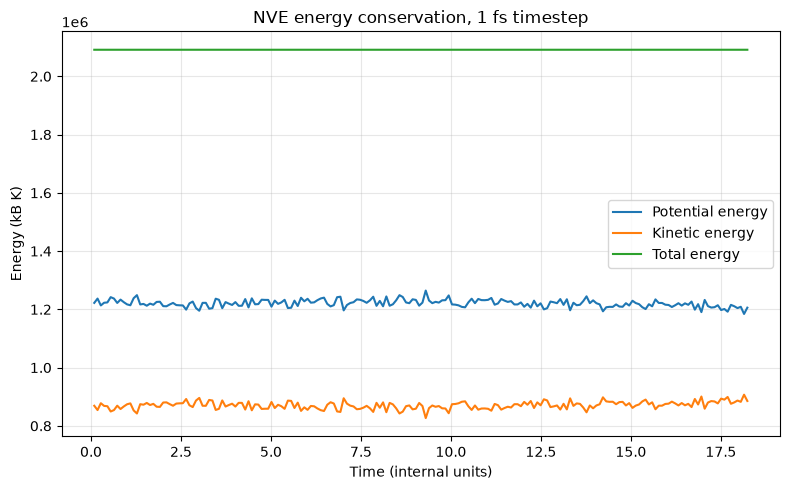

,Timestep (fs),Mean total energy,Energy slope,Relative drift / internal time,Relative bounded oscillation
0,1.0,2.091221e+06,-0.133443,-6.381095e-08,0.000005
1,0.5,2.091218e+06,-0.021845,-1.044604e-08,0.000001



Measured bounded-energy error ratio (1 fs / 0.5 fs) = 3.890
Expected ratio for second-order velocity-Verlet = 4.000


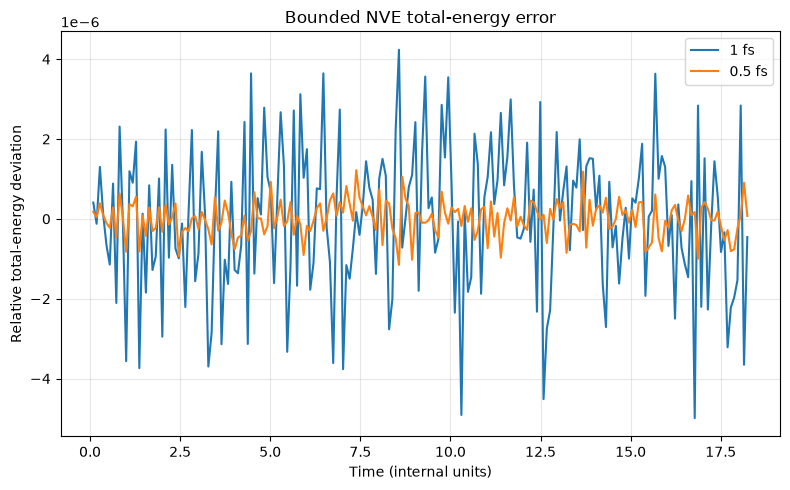

,Test,Relative error
0,Maximum particle force error,5.709060e-06
1,Virial error,1.360220e-09



Maximum force relative error = 5.709060e-06
Virial relative error        = 1.360220e-09
Finite-difference displacement = 1e-6 Angstrom
Accepted force tolerance       = 2e-5

Estimated absolute finite-difference force resolution = 4.336e-03


,Population,Mean temperature (K),Standard deviation (K),Target temperature (K)
0,Whole system,293.009230,1.447977,293.0
1,CH3,292.884826,7.586759,293.0
2,CH2,292.847991,4.668150,293.0



Mean total-system temperature = 293.009 K
Mean CH3 temperature          = 292.885 K
Mean CH2 temperature          = 292.848 K

CH3 - CH2 mean temperature difference = 0.037 K


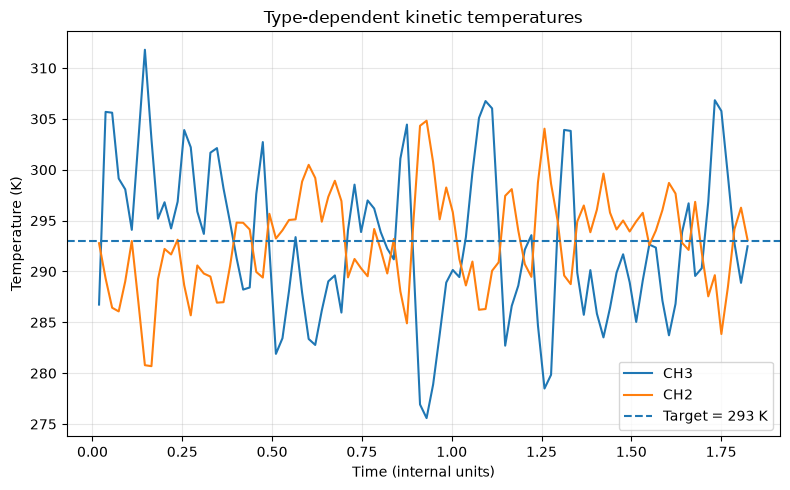


Finite-difference tolerance estimate
------------------------------------
Smallest tested analytical force = 1.359884e+02
Median tested analytical force   = 3.064184e+03
Absolute FD noise estimate        = 4.336366e-03
Worst estimated relative floor    = 3.188777e-05
Typical estimated relative floor  = 1.415178e-06
Observed maximum relative error   = 5.709060e-06
Chosen relative tolerance         = 2.000000e-05


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path


# ============================================================
# 1. Load simulation data
# ============================================================

nve_1fs = pd.read_csv(
    "data/b3_nve_1fs.csv",
    encoding="utf-16"
)

nve_05fs = pd.read_csv(
    "data/b3_nve_05fs.csv",
    encoding="utf-16"
)

type_temperature = pd.read_csv(
    "data/b3_type_temperature.csv",
    encoding="utf-16"
)

print("1 fs columns :", list(nve_1fs.columns))
print("0.5 fs columns:", list(nve_05fs.columns))
print("Temperature-check columns:", list(type_temperature.columns))


# ============================================================
# 2. Plot potential, kinetic and total energy
#    for the 1 fs NVE simulation
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nve_1fs["time"],
    nve_1fs["Epot"],
    label="Potential energy"
)

ax.plot(
    nve_1fs["time"],
    nve_1fs["Ekin"],
    label="Kinetic energy"
)

ax.plot(
    nve_1fs["time"],
    nve_1fs["Etot"],
    label="Total energy"
)

ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Energy (kB K)")
ax.set_title("NVE energy conservation, 1 fs timestep")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Function to determine systematic energy drift
#    and bounded energy oscillation
# ============================================================

def analyse_energy(data):

    t = data["time"].to_numpy(dtype=float)
    E = data["Etot"].to_numpy(dtype=float)

    # Linear least-squares fit:
    #
    # E(t) = slope * t + intercept
    #
    # The slope represents systematic energy drift.
    slope, intercept = np.polyfit(t, E, 1)

    E_mean = np.mean(E)

    # Relative systematic drift per internal time unit
    relative_drift = slope / abs(E_mean)

    # Linear fitted energy
    E_fit = slope * t + intercept

    # Remove systematic drift so that the remaining
    # variation represents the bounded integration error
    residual = E - E_fit

    # Half peak-to-peak amplitude of the bounded oscillation
    oscillation_abs = 0.5 * (
        np.max(residual) - np.min(residual)
    )

    # Relative bounded energy oscillation
    relative_oscillation = (
        oscillation_abs / abs(E_mean)
    )

    return {
        "mean_energy": E_mean,
        "slope": slope,
        "relative_drift": relative_drift,
        "oscillation_abs": oscillation_abs,
        "relative_oscillation": relative_oscillation,
        "residual": residual
    }


result_1fs = analyse_energy(nve_1fs)
result_05fs = analyse_energy(nve_05fs)


# ============================================================
# 4. Compare the 1 fs and 0.5 fs simulations
# ============================================================

energy_results = pd.DataFrame({

    "Timestep (fs)": [
        1.0,
        0.5
    ],

    "Mean total energy": [
        result_1fs["mean_energy"],
        result_05fs["mean_energy"]
    ],

    "Energy slope": [
        result_1fs["slope"],
        result_05fs["slope"]
    ],

    "Relative drift / internal time": [
        result_1fs["relative_drift"],
        result_05fs["relative_drift"]
    ],

    "Relative bounded oscillation": [
        result_1fs["relative_oscillation"],
        result_05fs["relative_oscillation"]
    ]
})

display(energy_results)


# Velocity-Verlet is second order, so when the timestep
# is halved the bounded energy error should decrease
# by approximately a factor of 4.

scaling = (
    result_1fs["relative_oscillation"]
    / result_05fs["relative_oscillation"]
)

print()
print(
    "Measured bounded-energy error ratio "
    f"(1 fs / 0.5 fs) = {scaling:.3f}"
)

print(
    "Expected ratio for second-order "
    "velocity-Verlet = 4.000"
)


# ============================================================
# 5. Plot the bounded total-energy errors
#    after removing systematic drift
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nve_1fs["time"],
    result_1fs["residual"]
    / abs(result_1fs["mean_energy"]),
    label="1 fs"
)

ax.plot(
    nve_05fs["time"],
    result_05fs["residual"]
    / abs(result_05fs["mean_energy"]),
    label="0.5 fs"
)

ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Relative total-energy deviation")
ax.set_title("Bounded NVE total-energy error")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Read finite-difference force-test results
# ============================================================

force_file = Path(
    "data/b3_force_test.txt"
)

text = force_file.read_text(
    encoding="utf-16"
)

particle_errors = [
    float(x)
    for x in re.findall(
        r"Particle .*?rel\.err=([0-9.eE+\-]+)",
        text
    )
]

if len(particle_errors) == 0:
    raise ValueError(
        "No particle force errors were found "
        "in b3_force_test.txt"
    )

max_force_error = max(
    particle_errors
)


virial_match = re.search(
    r"Virial test:.*rel\.err=([0-9.eE+\-]+)",
    text
)

if virial_match is None:
    raise ValueError(
        "Virial result could not be found "
        "in b3_force_test.txt"
    )

virial_error = float(
    virial_match.group(1)
)


fd_results = pd.DataFrame({

    "Test": [
        "Maximum particle force error",
        "Virial error"
    ],

    "Relative error": [
        max_force_error,
        virial_error
    ]
})

display(fd_results)

print()
print(
    f"Maximum force relative error = "
    f"{max_force_error:.6e}"
)

print(
    f"Virial relative error        = "
    f"{virial_error:.6e}"
)

print(
    "Finite-difference displacement = 1e-6 Angstrom"
)

print(
    "Accepted force tolerance       = 2e-5"
)


# ============================================================
# 7. Estimate finite-difference numerical resolution
# ============================================================

eps_machine = np.finfo(float).eps

U_scale = abs(
    nve_1fs["Epot"].mean()
)

delta = 1e-6

force_noise = (
    16.0
    * eps_machine
    * U_scale
    / delta
)

print()
print(
    "Estimated absolute finite-difference "
    f"force resolution = {force_noise:.3e}"
)


# ============================================================
# 8. CH3 / CH2 temperature check
# ============================================================

T_CH3_mean = type_temperature["T_CH3_K"].mean()
T_CH2_mean = type_temperature["T_CH2_K"].mean()

T_CH3_std = type_temperature["T_CH3_K"].std()
T_CH2_std = type_temperature["T_CH2_K"].std()

T_total_mean = type_temperature["T"].mean()
T_total_std = type_temperature["T"].std()


temperature_results = pd.DataFrame({

    "Population": [
        "Whole system",
        "CH3",
        "CH2"
    ],

    "Mean temperature (K)": [
        T_total_mean,
        T_CH3_mean,
        T_CH2_mean
    ],

    "Standard deviation (K)": [
        T_total_std,
        T_CH3_std,
        T_CH2_std
    ],

    "Target temperature (K)": [
        293.0,
        293.0,
        293.0
    ]
})

display(temperature_results)

print()

print(
    f"Mean total-system temperature = "
    f"{T_total_mean:.3f} K"
)

print(
    f"Mean CH3 temperature          = "
    f"{T_CH3_mean:.3f} K"
)

print(
    f"Mean CH2 temperature          = "
    f"{T_CH2_mean:.3f} K"
)

print()

print(
    f"CH3 - CH2 mean temperature difference = "
    f"{T_CH3_mean - T_CH2_mean:.3f} K"
)


# ============================================================
# 9. Plot CH3 and CH2 instantaneous temperatures
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    type_temperature["time"],
    type_temperature["T_CH3_K"],
    label="CH3"
)

ax.plot(
    type_temperature["time"],
    type_temperature["T_CH2_K"],
    label="CH2"
)

ax.axhline(
    293.0,
    linestyle="--",
    label="Target = 293 K"
)

ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Type-dependent kinetic temperatures")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 10. Justify the finite-difference tolerance
# ============================================================
#
# force_test.c estimates the absolute finite-difference
# resolution approximately as
#
# noise ~ 16 * eps_machine * |U| / delta
#
# This is an ABSOLUTE force uncertainty.
#
# To estimate the corresponding worst-case RELATIVE error,
# divide this noise floor by the smallest force magnitude
# actually tested.
# ============================================================


# Extract analytical force vectors from the force-test output
force_matches = re.findall(
    r"Particle\s+\d+:\s+Force analytical:\s*"
    r"\(\s*([0-9.eE+\-]+)\s*,\s*"
    r"([0-9.eE+\-]+)\s*,\s*"
    r"([0-9.eE+\-]+)\s*\)",
    text
)


analytical_force_magnitudes = []

for fx, fy, fz in force_matches:

    fx = float(fx)
    fy = float(fy)
    fz = float(fz)

    magnitude = np.sqrt(
        fx**2 + fy**2 + fz**2
    )

    analytical_force_magnitudes.append(
        magnitude
    )


analytical_force_magnitudes = np.array(
    analytical_force_magnitudes
)


# Ignore exactly zero forces, if any
nonzero_forces = analytical_force_magnitudes[
    analytical_force_magnitudes > 0
]


min_force = np.min(
    nonzero_forces
)

median_force = np.median(
    nonzero_forces
)


# We already estimated the absolute numerical
# finite-difference resolution as force_noise.
worst_relative_floor = (
    force_noise / min_force
)

typical_relative_floor = (
    force_noise / median_force
)


print()
print("Finite-difference tolerance estimate")
print("------------------------------------")

print(
    f"Smallest tested analytical force = "
    f"{min_force:.6e}"
)

print(
    f"Median tested analytical force   = "
    f"{median_force:.6e}"
)

print(
    f"Absolute FD noise estimate        = "
    f"{force_noise:.6e}"
)

print(
    f"Worst estimated relative floor    = "
    f"{worst_relative_floor:.6e}"
)

print(
    f"Typical estimated relative floor  = "
    f"{typical_relative_floor:.6e}"
)

print(
    f"Observed maximum relative error   = "
    f"{max_force_error:.6e}"
)

print(
    "Chosen relative tolerance         = "
    "2.000000e-05"
)

### B4) Bonded forces

Implement the bond, angle and torsion forces (both dihedrals of each
pentane molecule; one routine serves both).

### B5) Test the bonded forces

Finite-difference verification **per bonded term**, on a single molecule,
plus long-time NVE energy conservation for that single molecule.

Test the forces from a **thermalised** molecule, not from the one your
initialisation builds. A freshly built chain sits exactly at the minimum
of its bond, angle and torsion terms, so all three bonded forces are zero
there and the check compares round-off with round-off: it reports large
relative errors on perfectly correct code, and it would equally pass code
that is wrong. Run the molecule at the target temperature first and test
from that configuration.

Deliver:

- a **table** with one row per bonded term (bond, angle, torsion), giving
  the largest relative force error against finite differences;
- a **figure** of the energy of the single-molecule NVE run against time;
- the **check on the torsion**: the numerical values of the sum of the
  four torsion forces and of the net torque they produce, which should
  both be zero to round-off. Report the numbers, not the intention.

*Results (B4, B5):* …

First rows:


,step,time,Epot,Ekin,Etot,T,T_CH3_K,T_CH2_K
0,20,0.018236,26.609968,1731.944185,1758.554153,288.657364,487.250385,60.042896
1,40,0.036472,20.716715,1737.773636,1758.490351,289.628939,485.137318,62.747040
2,60,0.054708,15.573964,1742.941492,1758.515456,290.490249,463.130866,78.566421
3,80,0.072944,12.129966,1746.573752,1758.703719,291.095625,450.869083,87.548112
4,100,0.091180,7.384322,1751.112686,1758.497008,291.852114,429.683703,102.680350



Last rows:


,step,time,Epot,Ekin,Etot,T,T_CH3_K,T_CH2_K
4995,99920,91.107056,45.127859,1713.517025,1758.644883,285.586171,436.297793,89.916365
4996,99940,91.125292,16.499034,1742.004413,1758.503448,290.334069,470.792828,73.250207
4997,99960,91.143528,11.800026,1746.736183,1758.536208,291.122697,454.992903,84.834994
4998,99980,91.161764,-19.962453,1778.494385,1758.531932,296.415731,416.543325,117.525425
4999,100000,91.180000,21.313727,1737.357953,1758.671679,289.559659,448.841798,86.851680


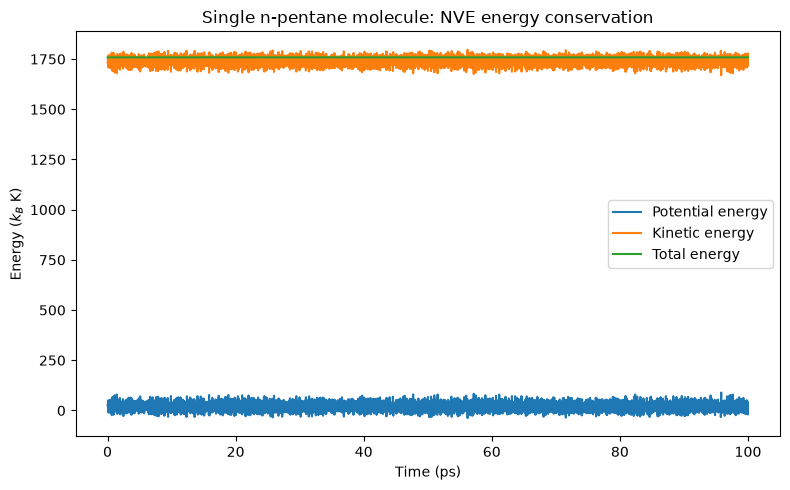


B5 NVE ENERGY CONSERVATION
Number of saved samples          = 5000
Simulation time                  = 99.980000 ps
Mean total energy                = 1758.56842961 kB K
Initial saved total energy       = 1758.5541532 kB K
Final total energy               = 1758.67167944 kB K
First-to-last energy change      = 1.175262e-01 kB K
Relative first-to-last change    = 6.683063e-05
Linear energy drift              = 2.006824e-06 kB K / ps
Relative linear drift            = 1.141169e-09 per ps
Total observed energy range      = 4.382659e-01 kB K
Relative observed energy range   = 2.492174e-04
Detrended half-range             = 2.190707e-01 kB K
Relative detrended half-range    = 1.245733e-04
Standard deviation of Etot       = 8.239123e-02 kB K
Relative standard deviation      = 4.685131e-05


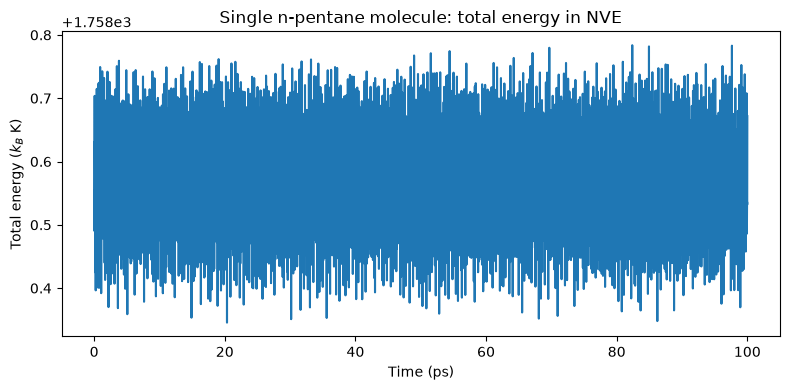

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Load B5 single-molecule NVE trajectory
# ---------------------------------------------------------

# PowerShell redirected the file in UTF-16, so specify the encoding explicitly.
b5_nve = pd.read_csv(
    "data/b5_nve.csv",
    encoding="utf-16"
)

print("First rows:")
display(b5_nve.head())

print("\nLast rows:")
display(b5_nve.tail())


# ---------------------------------------------------------
# Convert internal time to ps
# ---------------------------------------------------------

# 1 fs = 0.0009118 internal time units
# therefore 1 ps = 0.9118 internal time units
b5_nve["time_ps"] = b5_nve["time"] / 0.9118


# ---------------------------------------------------------
# Plot potential, kinetic and total energy
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    b5_nve["time_ps"],
    b5_nve["Epot"],
    label="Potential energy"
)

plt.plot(
    b5_nve["time_ps"],
    b5_nve["Ekin"],
    label="Kinetic energy"
)

plt.plot(
    b5_nve["time_ps"],
    b5_nve["Etot"],
    label="Total energy"
)

plt.xlabel("Time (ps)")
plt.ylabel(r"Energy ($k_B$ K)")
plt.title("Single n-pentane molecule: NVE energy conservation")
plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Quantitative energy-conservation analysis
# ---------------------------------------------------------

time = b5_nve["time_ps"].to_numpy()
Etot = b5_nve["Etot"].to_numpy()

# Mean total energy
mean_E = np.mean(Etot)

# Linear fit:
# Etot(t) = slope * t + intercept
slope, intercept = np.polyfit(
    time,
    Etot,
    1
)

# Relative linear drift per ps
relative_slope_per_ps = slope / mean_E


# ---------------------------------------------------------
# First-to-last change
# ---------------------------------------------------------

delta_E = Etot[-1] - Etot[0]

relative_delta_E = (
    delta_E / mean_E
)


# ---------------------------------------------------------
# Full observed energy range
# ---------------------------------------------------------

energy_range = (
    Etot.max() - Etot.min()
)

relative_range = (
    energy_range / mean_E
)


# ---------------------------------------------------------
# Remove linear drift to inspect bounded numerical
# oscillations from velocity-Verlet
# ---------------------------------------------------------

trend = (
    slope * time + intercept
)

detrended = (
    Etot - trend
)

detrended_half_range = (
    detrended.max()
    - detrended.min()
) / 2.0

relative_detrended_half_range = (
    detrended_half_range / mean_E
)


# ---------------------------------------------------------
# Additional standard deviation metric
# ---------------------------------------------------------

energy_std = np.std(
    Etot,
    ddof=1
)

relative_energy_std = (
    energy_std / mean_E
)


# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("\nB5 NVE ENERGY CONSERVATION")
print("=" * 60)

print(
    f"Number of saved samples          = {len(b5_nve)}"
)

print(
    f"Simulation time                  = "
    f"{time[-1] - time[0]:.6f} ps"
)

print(
    f"Mean total energy                = "
    f"{mean_E:.12g} kB K"
)

print(
    f"Initial saved total energy       = "
    f"{Etot[0]:.12g} kB K"
)

print(
    f"Final total energy               = "
    f"{Etot[-1]:.12g} kB K"
)

print(
    f"First-to-last energy change      = "
    f"{delta_E:.6e} kB K"
)

print(
    f"Relative first-to-last change    = "
    f"{relative_delta_E:.6e}"
)

print(
    f"Linear energy drift              = "
    f"{slope:.6e} kB K / ps"
)

print(
    f"Relative linear drift            = "
    f"{relative_slope_per_ps:.6e} per ps"
)

print(
    f"Total observed energy range      = "
    f"{energy_range:.6e} kB K"
)

print(
    f"Relative observed energy range   = "
    f"{relative_range:.6e}"
)

print(
    f"Detrended half-range             = "
    f"{detrended_half_range:.6e} kB K"
)

print(
    f"Relative detrended half-range    = "
    f"{relative_detrended_half_range:.6e}"
)

print(
    f"Standard deviation of Etot       = "
    f"{energy_std:.6e} kB K"
)

print(
    f"Relative standard deviation      = "
    f"{relative_energy_std:.6e}"
)


# ---------------------------------------------------------
# Optional second figure:
# total energy only, zoomed in
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    b5_nve["time_ps"],
    b5_nve["Etot"]
)

plt.xlabel("Time (ps)")
plt.ylabel(r"Total energy ($k_B$ K)")
plt.title("Single n-pentane molecule: total energy in NVE")

plt.tight_layout()
plt.show()

### B4–B5) Bonded forces and verification

The harmonic bond, harmonic angle, and Ryckaert-Bellemans torsion forces were implemented for n-pentane. The forces were tested independently using a thermalised single n-pentane molecule, as required for B5.

The analytical forces were compared with central finite-difference estimates of the corresponding potential-energy gradients. The largest relative force errors were:

| Bonded interaction | Maximum relative force error |
|---|---:|
| Bond | $1.00916 \times 10^{-9}$ |
| Angle | $1.15294 \times 10^{-9}$ |
| Torsion | $2.11279 \times 10^{-8}$ |

The very small errors show that the analytical bond, angle, and torsion forces agree closely with the numerical derivatives of their respective potentials.

The torsion forces were additionally checked for conservation of total force and total torque. The results were:

| Torsion | $|\sum \mathbf{F}|$ | $|\tau_{\mathrm{net}}|$ |
|---|---:|---:|
| 0-1-2-3 | $1.77636 \times 10^{-15}$ | $7.90670 \times 10^{-13}$ |
| 1-2-3-4 | $2.92964 \times 10^{-14}$ | $3.37489 \times 10^{-13}$ |

The relative force residuals were $7.34 \times 10^{-18}$ and $4.65 \times 10^{-17}$ for the two torsions, respectively. The relative torque residuals were $2.32 \times 10^{-15}$ and $3.81 \times 10^{-16}$. These residuals are at the level of floating-point round-off.

Long-time energy conservation was tested by propagating the same thermalised single molecule for approximately $100$ ps in the NVE ensemble using a timestep of $1$ fs.

The mean total energy was

$$
\langle E_{\mathrm{tot}} \rangle = 1758.56843 \; k_B K.
$$

A linear fit to the total energy gave a relative energy drift of

$$
1.14 \times 10^{-9} \; \mathrm{ps}^{-1}.
$$

After removing the linear trend, the relative half-range of the bounded total-energy oscillations was

$$
1.25 \times 10^{-4}.
$$

The kinetic and potential energies fluctuate as energy is exchanged between the different degrees of freedom, while the total energy remains approximately constant over the full trajectory. This demonstrates stable long-time energy conservation in the NVE simulation.

### B6) Initialization

Devise a procedure to pack $N$ pentane molecules in a cubic box at the
target density with a sane starting structure (reasonable internal
geometry, and no overlap so severe that the first step throws a molecule
across the box), and assign velocities from the Maxwell-Boltzmann
distribution at the target temperature.

Deliver: a description of your procedure, the box size and $N$ you chose
with the arithmetic that connects them to $\rho = 626\ \mathrm{kg/m^3}$,
the **closest interacting pair distance** your configuration starts with
next to $\sigma$, and a **rendering** of the starting configuration. Open
it in OVITO and look at it, which is the point of the exercise; the figure
in your report may come from OVITO, from VMD, or from your own plot of the
`.pdb`, as long as it travels in the zip.

A lattice of chains is not a liquid, and a packing dense enough to hit the
target density will have pairs inside $\sigma$. That is expected. B7 is
where you measure what they cost.

### B7) Energy conservation of the full system

From the packed configuration, run NVE and check energy conservation.

Deliver a **figure** of $E_\mathrm{tot}$, $E_\mathrm{kin}$,
$E_\mathrm{pot}$ and $T$ against time, and an explanation of the initial
transient: the temperature moves within the first picoseconds even though
the total energy does not. Where does that kinetic energy come from, and
what does it tell you about your starting structure?

*Results (B6, B7):* …

B7 NVE results
Simulation time: 19.999 ps
Mean total energy: -73747.483 kB K
Relative energy drift: -1.149e-05 per ps
Approximate systematic drift over the full run: -0.0230 %
Mean temperature over final 100 samples: 203.49 K


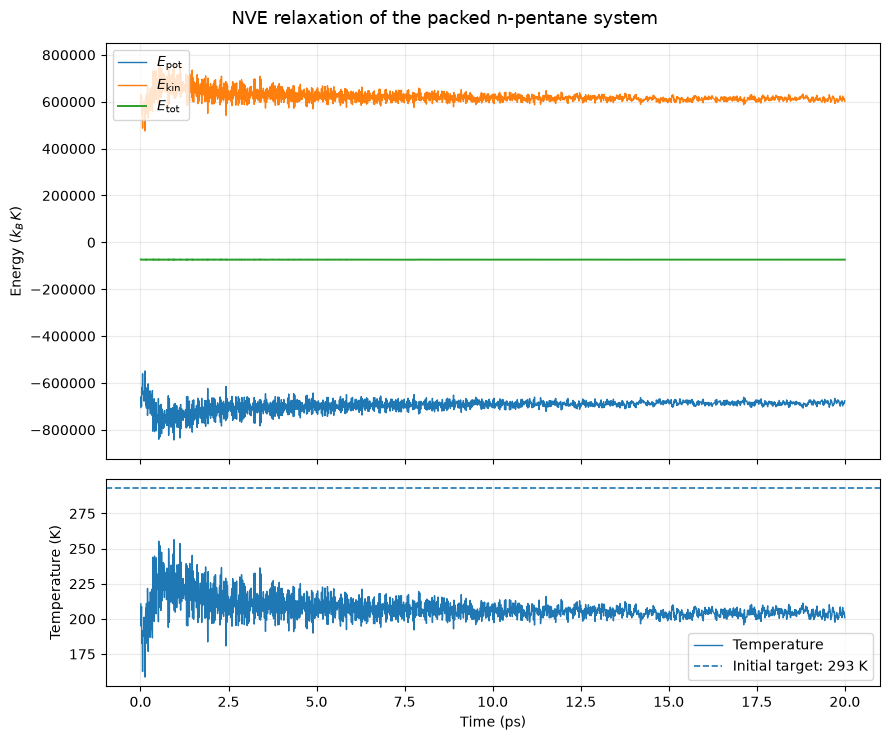

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# B7 - NVE energy conservation of the full pentane system
# ============================================================

filename = "data/b7_nve.csv"

# Load simulation output
try:
    df = pd.read_csv(filename)
except UnicodeError:
    df = pd.read_csv(filename, encoding="utf-16")

# Convert internal simulation time to ps
time_ps = df["time"] * 1.0967

# Extract quantities
Epot = df["Epot"].to_numpy()
Ekin = df["Ekin"].to_numpy()
Etot = df["Etot"].to_numpy()
T = df["T"].to_numpy()

# ------------------------------------------------------------
# Energy-conservation metrics
# ------------------------------------------------------------

mean_Etot = np.mean(Etot)

slope, intercept = np.polyfit(time_ps, Etot, 1)
relative_drift_per_ps = slope / abs(mean_Etot)

total_relative_drift = (
    relative_drift_per_ps * time_ps.iloc[-1]
)

print("B7 NVE results")
print(f"Simulation time: {time_ps.iloc[-1]:.3f} ps")
print(f"Mean total energy: {mean_Etot:.3f} kB K")
print(
    f"Relative energy drift: "
    f"{relative_drift_per_ps:.3e} per ps"
)
print(
    f"Approximate systematic drift over the full run: "
    f"{100 * total_relative_drift:.4f} %"
)
print(
    f"Mean temperature over final 100 samples: "
    f"{np.mean(T[-100:]):.2f} K"
)

# ============================================================
# B7 figure
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(9, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ------------------------------------------------------------
# Panel 1: energies
# ------------------------------------------------------------

ax1.plot(
    time_ps,
    Epot,
    label=r"$E_{\mathrm{pot}}$",
    linewidth=1.0
)

ax1.plot(
    time_ps,
    Ekin,
    label=r"$E_{\mathrm{kin}}$",
    linewidth=1.0
)

ax1.plot(
    time_ps,
    Etot,
    label=r"$E_{\mathrm{tot}}$",
    linewidth=1.4
)

ax1.set_ylabel(r"Energy ($k_B\,K$)")
ax1.legend()
ax1.grid(alpha=0.25)

# ------------------------------------------------------------
# Panel 2: temperature
# ------------------------------------------------------------

ax2.plot(
    time_ps,
    T,
    label="Temperature",
    linewidth=1.0
)

ax2.axhline(
    293.0,
    linestyle="--",
    linewidth=1.2,
    label="Initial target: 293 K"
)

ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(alpha=0.25)

# Overall figure title
fig.suptitle(
    "NVE relaxation of the packed n-pentane system",
    fontsize=13
)

plt.tight_layout()
plt.show()

### B6) Initialization

A system of \(N = 400\) n-pentane molecules was initialized. Since each molecule contains 5 united-atom sites,

$$
N_{\text{sites}} = 400 \times 5 = 2000.
$$

Each pentane molecule contains two CH3 sites and three CH2 sites. The molecular mass is therefore

$$
M = 2(15.035) + 3(14.027) = 72.151\ \mathrm{amu}.
$$

The total mass in the simulation box is

$$
m = 400 \times 72.151 \times 1.66054 \times 10^{-27}
$$

$$
m = 4.7924 \times 10^{-23}\ \mathrm{kg}.
$$

Using the target density

$$
\rho = 626\ \mathrm{kg\,m^{-3}},
$$

the required volume is

$$
V = \frac{m}{\rho}
$$

$$
V =
\frac{4.7924 \times 10^{-23}}{626}
=
7.6556 \times 10^{-26}\ \mathrm{m^3}.
$$

For a cubic simulation box,

$$
L = V^{1/3}
$$

$$
L = 4.2461 \times 10^{-9}\ \mathrm{m}
= 42.461\ \mathrm{\AA}.
$$

The 400 molecular centres were placed on a \(10 \times 10 \times 4\) grid. Each molecule was constructed using the equilibrium bond length

$$
r_0 = 1.54\ \mathrm{\AA}
$$

and equilibrium bond angle

$$
\theta_0 = 114^\circ.
$$

The molecules were initially constructed in an all-trans geometry. Their zig-zag planes were randomly rotated around the molecular long axis. This produced a dense starting configuration while maintaining reasonable intramolecular geometry.

Initial velocities were sampled from a Maxwell-Boltzmann distribution at

$$
T = 293\ \mathrm{K},
$$

using the appropriate mass for each CH3 and CH2 site. The total centre-of-mass momentum was then removed.

The closest pair for which a Lennard-Jones interaction is evaluated was a CH2-CH2 pair with distance

$$
r_{\min} = 3.240\ \mathrm{\AA}.
$$

For a CH2-CH2 interaction,

$$
\sigma = 3.95\ \mathrm{\AA}.
$$

Therefore,

$$
\frac{r_{\min}}{\sigma}
=
\frac{3.240}{3.95}
=
0.820.
$$

The closest interacting pair therefore starts inside \(\sigma\), which is expected for this dense artificial packing. Visual inspection of the starting configuration shows that the simulation box is filled without catastrophic overlaps, although the ordered arrangement is clearly not yet an equilibrated liquid.

The starting configuration is shown in the B6 rendering above.


### B7) Energy conservation of the full system

The packed configuration from B6 was propagated in the NVE ensemble using a timestep of

$$
\Delta t = 1\ \mathrm{fs}
$$

for approximately

$$
20\ \mathrm{ps}.
$$

The thermostat was disabled so that energy conservation could be tested directly.

A linear fit to the total energy gave a relative drift of

$$
\frac{1}{|E_{\mathrm{tot}}|}
\frac{dE_{\mathrm{tot}}}{dt}
=
-1.15 \times 10^{-5}\ \mathrm{ps^{-1}}.
$$

Over the complete 20 ps simulation, this corresponds to an approximate systematic change of

$$
0.023\%.
$$

The total energy therefore remains approximately constant during the NVE simulation.

A strong transient is observed during the first few picoseconds. Although the initial velocities were sampled from a Maxwell-Boltzmann distribution corresponding to \(293\ \mathrm{K}\), the temperature decreases and later fluctuates around approximately \(200\) to \(205\ \mathrm{K}\).

Assigning velocities at \(293\ \mathrm{K}\) only fixes the initial kinetic energy. It does not mean that the complete molecular configuration is already at equilibrium. The B6 configuration was generated artificially on an ordered grid and therefore contains intermolecular contacts that are not representative of an equilibrated liquid.

During the initial NVE relaxation, kinetic and potential energy are exchanged while

$$
E_{\mathrm{tot}}
=
E_{\mathrm{kin}}
+
E_{\mathrm{pot}}
$$

remains approximately constant.

In this simulation, the potential energy becomes less negative during the initial relaxation. The potential energy therefore increases while the kinetic energy decreases. Since temperature is directly related to kinetic energy, the temperature consequently decreases.

The initial temperature transient therefore results from relaxation of the artificial packed structure rather than from loss of total energy. This shows that the B6 configuration is a reasonable starting configuration, but it is not yet an equilibrated liquid.


### B8) Thermostat

Implement the Berendsen thermostat for NVT runs.

### B9) Test the thermostat

Starting from the packed configuration, run NVT and verify equilibration
to the target temperature.

Deliver:

- a **figure** of the temperature against time for NVE and for NVT, with
  **two values of the coupling time $\tau$**, on one set of axes;
- a **table** of the mean temperature and its fluctuation over the
  equilibrated part of each run, next to the target 293 K;
- a comment on the trade-off: what does a very short $\tau$ buy you, and
  what does it cost? What is the Berendsen thermostat *not* guaranteed to
  give you, however well it holds the mean temperature?

*Results (B8, B9):* …

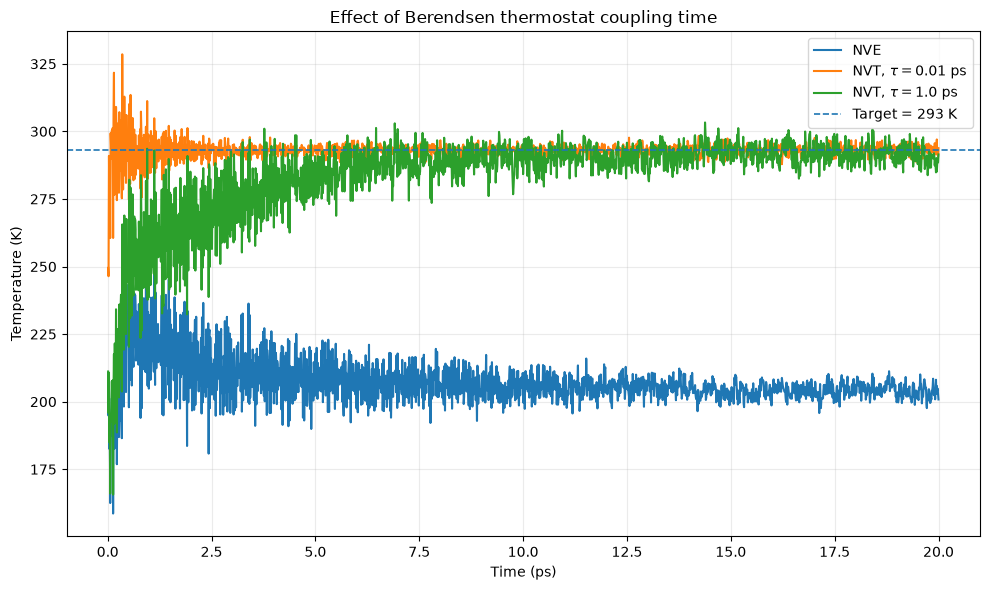

Temperature statistics calculated over the final 5 ps (t >= 15 ps):


,Run,Target T (K),Mean T (K),"Temperature fluctuation, std (K)"
0,NVE,293.0,204.07,2.61
1,"NVT, tau = 0.01 ps",293.0,292.99,1.62
2,"NVT, tau = 1.0 ps",293.0,291.67,3.52


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# B9 - Test of the Berendsen thermostat
# ============================================================

# Load the three simulations
def load_csv(filename):
    try:
        return pd.read_csv(filename)
    except UnicodeError:
        return pd.read_csv(filename, encoding="utf-16")


nve = load_csv("data/b7_nve.csv")
nvt_fast = load_csv("data/b9_nvt_tau001.csv")
nvt_slow = load_csv("data/b9_nvt_tau1.csv")


# ------------------------------------------------------------
# Convert internal time to ps
# ------------------------------------------------------------

conversion = 1.0967

t_nve = nve["time"] * conversion
t_fast = nvt_fast["time"] * conversion
t_slow = nvt_slow["time"] * conversion


# ============================================================
# Figure: temperature versus time
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    t_nve,
    nve["T"],
    label="NVE"
)

plt.plot(
    t_fast,
    nvt_fast["T"],
    label=r"NVT, $\tau = 0.01$ ps"
)

plt.plot(
    t_slow,
    nvt_slow["T"],
    label=r"NVT, $\tau = 1.0$ ps"
)

plt.axhline(
    293.0,
    linestyle="--",
    linewidth=1.2,
    label="Target = 293 K"
)

plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("Effect of Berendsen thermostat coupling time")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# Equilibrated temperature statistics
# ============================================================

# Use the final 5 ps of each trajectory as the analysis window.
equilibration_start = 15.0

mask_nve = t_nve >= equilibration_start
mask_fast = t_fast >= equilibration_start
mask_slow = t_slow >= equilibration_start


def temperature_statistics(data, mask):
    values = data.loc[mask, "T"]

    return (
        values.mean(),
        values.std(ddof=1)
    )


mean_nve, std_nve = temperature_statistics(nve, mask_nve)
mean_fast, std_fast = temperature_statistics(nvt_fast, mask_fast)
mean_slow, std_slow = temperature_statistics(nvt_slow, mask_slow)


# ============================================================
# Table
# ============================================================

results = pd.DataFrame({
    "Run": [
        "NVE",
        "NVT, tau = 0.01 ps",
        "NVT, tau = 1.0 ps"
    ],

    "Target T (K)": [
        293.0,
        293.0,
        293.0
    ],

    "Mean T (K)": [
        mean_nve,
        mean_fast,
        mean_slow
    ],

    "Temperature fluctuation, std (K)": [
        std_nve,
        std_fast,
        std_slow
    ]
})

results = results.round(2)

print(
    "Temperature statistics calculated over the final 5 ps "
    "(t >= 15 ps):"
)

display(results)

### B9) Test of the thermostat

The Berendsen thermostat was tested using two coupling times and compared with the NVE trajectory from B7. The same packed starting configuration was used in all three simulations.

The two thermostat coupling times were

$$
\tau = 0.01\ \mathrm{ps}
$$

and

$$
\tau = 1.0\ \mathrm{ps}.
$$

Temperature statistics were calculated over the final 5 ps of each trajectory, after the initial relaxation.

For the NVE simulation, the temperature remains well below the target temperature and has a mean value of approximately

$$
T_{\mathrm{NVE}} = 204.07\ \mathrm{K}.
$$

This is consistent with the relaxation observed in B7, where kinetic energy is converted into potential energy while the total energy remains approximately constant.

With the Berendsen thermostat active, both NVT simulations approach the target temperature of

$$
T_0 = 293\ \mathrm{K}.
$$

For the strongly coupled thermostat, with

$$
\tau = 0.01\ \mathrm{ps},
$$

the mean temperature over the final 5 ps is

$$
T = 292.99\ \mathrm{K},
$$

with a standard deviation of approximately

$$
1.62\ \mathrm{K}.
$$

For the weaker coupling,

$$
\tau = 1.0\ \mathrm{ps},
$$

the mean temperature is

$$
T = 291.67\ \mathrm{K},
$$

with a larger standard deviation of approximately

$$
3.52\ \mathrm{K}.
$$

A very short coupling time therefore brings the system to the target temperature much more rapidly and keeps the instantaneous temperature close to the target. However, this strong coupling also perturbs the natural dynamics more strongly because the particle velocities are rescaled more aggressively.

A longer coupling time affects the dynamics less strongly and allows larger natural temperature fluctuations, but equilibration to the target temperature is slower.

An important limitation of the Berendsen thermostat is that it is not guaranteed to generate the correct canonical ensemble. In particular, even when the mean temperature is close to the desired value, the correct distribution and magnitude of temperature and energy fluctuations are not guaranteed. Strong Berendsen coupling can suppress these fluctuations artificially.

## Part C: Production runs and analysis

*In the oral you should be able to:* predict how each observable moves
when temperature, density or a force-field parameter changes; explain the
pentane effect from the force field; defend where your MSD fit starts and
your error estimate for $D$.

Part C is measurement, so every number needs an uncertainty and every
figure needs axis labels with units, a legend, and a sentence stating
what the reader should conclude.

**Equilibrate before you sample, and check that you did.** Both
measurements below have their own relaxation time, and neither is short:
the conformer populations relax over tens of picoseconds, and so does the
sharing of kinetic energy between the chain ends and the chain interior
after the starting lattice melts. Sampling from a configuration that is
still relaxing biases the answer in a direction you can predict but will
not see. Discard enough of the beginning of each production run that the
quantity you are about to measure has stopped drifting, and say in your
report how you decided how much was enough.

### C1) Conformational analysis: the two dihedrals of pentane

Pentane has two coupled torsion angles $(\phi_1, \phi_2)$. Classify each
as *trans* ($t$, near $180^\circ$) or *gauche* ($g^+$ or $g^-$, near
$\pm 60^\circ$) and measure the populations of the *pair* states.

Deliver:

- a **figure**: the joint distribution of $(\phi_1,\phi_2)$ as a 2D
  histogram, with the state regions identifiable;
- a **figure**: the one-dimensional distribution of a single dihedral,
  with the *trans* and *gauche* minima marked;
- a **table** of the pair-state populations. Think about which states are
  equivalent by symmetry before you present nine numbers, and give each
  population an error estimate;
- **the pentane effect:** compare $g^+g^+$ with $g^+g^-$ explicitly.
  Explain the difference *from the force field*: which interaction
  penalises $g^+g^-$, and what happens geometrically to the two end
  groups in that conformation?
- **convergence:** the barriers are several $k_BT$, so transitions are
  rare events. Estimate, or measure from your trajectory, the mean time a
  molecule spends in a state, and use it to argue how long a run must be
  for the populations to be converged. Compare that with the length of
  the run you actually did, and say honestly whether your populations are
  converged.

*Results and discussion (C1):* …

In [37]:
# C1: joint (phi1, phi2) histogram, single-dihedral distribution, pair-state table

### C2) Diffusion coefficient

Implement creation and on-the-fly updating of the mean squared
displacement of the *molecular centres of mass*, and extract the
self-diffusion coefficient $D$ from the long-time slope,
$\langle \Delta r^2 \rangle \to 6Dt$.

Deliver:

- a **figure** of the MSD against time on log-log axes, with the
  ballistic ($\propto t^2$) and diffusive ($\propto t$) regimes marked,
  and the fit window shown;
- **the value of $D$** in internal units and in $\mathrm{m^2/s}$, with an
  **error estimate** and a statement of how you obtained it (for example
  by splitting the trajectory into blocks and comparing);
- a sentence justifying where your fit window starts and ends: why not
  earlier, why not later?

Then compare your $D$ with an experimental value for liquid pentane if
you can find one, and say what a disagreement would mean: an error in
your code, or a limitation of the model?

*Results (C2):* $D$ = … (internal) = … m²/s; fit window …; error …

In [38]:
# C2: MSD vs time (log-log), fit window, D extraction with error estimate

## Lessons learned

What would you do differently if you started over? What surprised you?
What in your results still bothers you? (Standing questions in the oral,
so write the honest version.)

*Lessons learned:* …

## Hand-in

One zip per group, layout exactly:

```
<group>_A2.zip
├── A2.ipynb     this notebook, filled in and executed
│                (all outputs present; task cells untouched)
├── A2.html      python3 nb2html.py A2.ipynb
├── code/        all .c/.h + README.md; must build with
│                gcc -O3 *.c -o md -lm    (no binaries)
└── data/        every data file this notebook loads
```

Long production runs are done in the terminal; record the exact commands
in the *Build & run log* and let the notebook load the saved output from
`data/`. Handed in executed, the notebook must open and display without
rerunning anything.

Write the path of every data file your notebook opens out in full, as
`"data/run.csv"` rather than assembling it from a variable. The checker
below looks for those paths literally, and it will report a file as
missing if it cannot see the name.

**Before you submit,** check your own zip:

```
python3 check_my_submission.py <group>_A2.zip --release A2.ipynb
```

where `--release` is a freshly downloaded, unmodified `A2.ipynb`. It
verifies the layout, that the task cells are untouched, that every cell
has been executed, that your C code compiles, and that every path and
link in the notebook is relative and present in the zip. Fix what it
reports, then submit. Setting up the Python environment
(`requirements.txt`, both helper scripts) is described on the Canvas page
*Working on the assignments*.